In [2]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/image-to-black-white/src")

import cv2
import numpy as np
from matplotlib import pyplot as plt

In [3]:
nazwy_plikow = [
    # "../out/image1.jpg",
    "../out/image2.jpg",
    "../out/image3.jpg",
    "../out/image4.jpg",
    "../out/image5.jpg",
    "../out/image6.jpg"
]

images = []

for file_name in nazwy_plikow:
    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

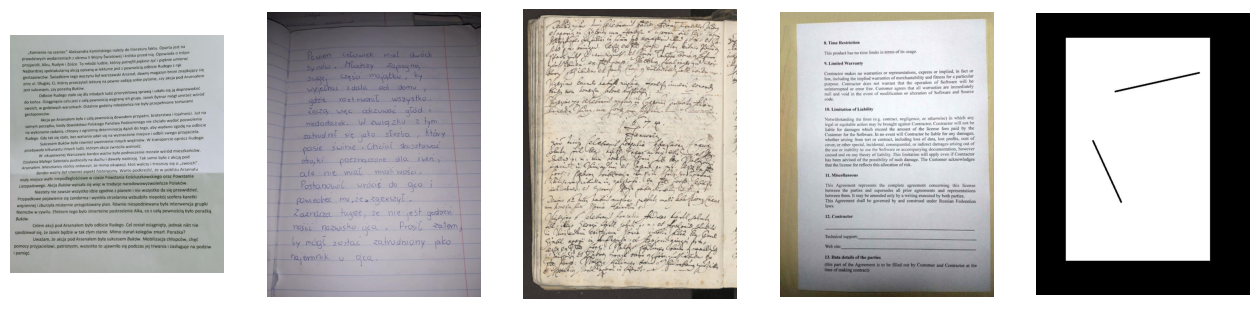

In [4]:
fig = plt.figure(figsize=(16, 8))

for i, img in enumerate(images):
    fig.add_subplot(1, len(images), i + 1)
    
    # plt.imshow(img)
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    plt.axis('off')
    
plt.show()

In [30]:
image = images[1]

height, width = image.shape[:2]

src_points = np.float32([
    [125, 125],
    [595, 125],
    [665, 875],
    [70, 875]
])

dst_points = np.float32([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
])

In [31]:
matrix = cv2.getPerspectiveTransform(src_points, dst_points)

warped = cv2.warpPerspective(image, matrix, (width, height))

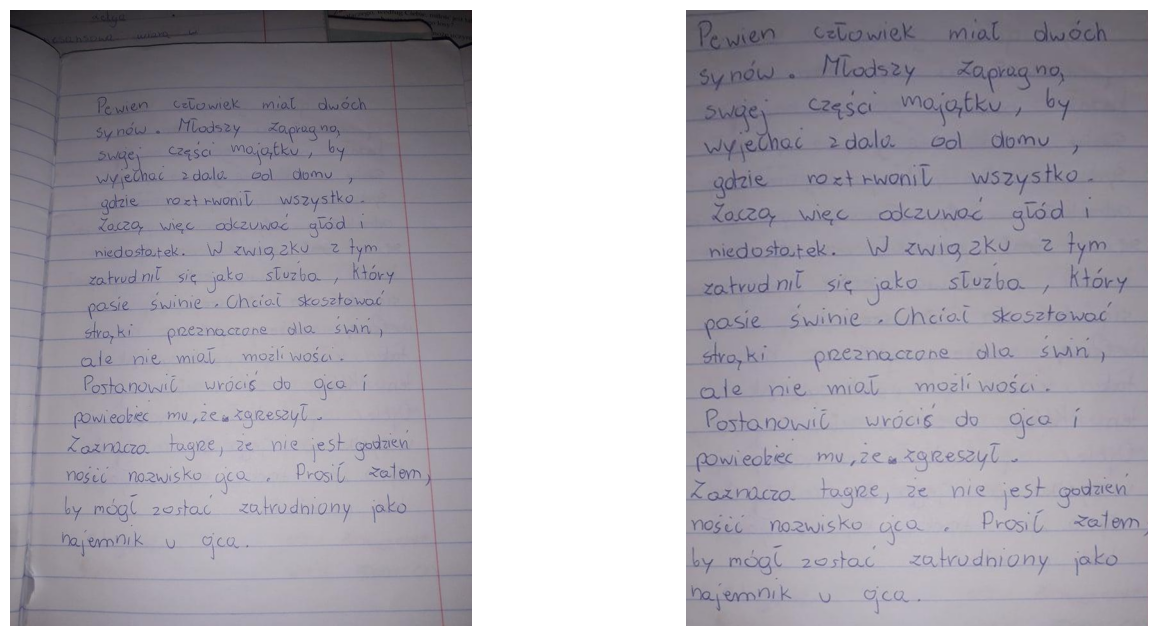

In [32]:
fig = plt.figure(figsize=(16, 8))

fig.add_subplot(1, 2, 1)
plt.axis("off")
plt.imshow(image)

fig.add_subplot(1, 2, 2)
plt.axis("off")
plt.imshow(warped)

plt.show()